# YOLO11n-Pose Training on LV-MHP-v2

Finetune YOLO11n-pose on LV-MHP-v2 dataset with 16 body keypoints.

**Setup:** Runtime > Change runtime type > **GPU (T4)** or **TPU**

## 1. Install Dependencies

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00


## 2. Check Hardware

In [2]:
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Check for TPU
try:
    import torch_xla.core.xla_model as xm
    print(f"TPU available: {xm.xla_device()}")
except ImportError:
    print("TPU: not available (GPU runtime selected)")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB
TPU: not available (GPU runtime selected)


## 3. Mount Google Drive

Upload your `LV-MHP-v2-pose` folder to Google Drive before running this cell.

Expected structure on Drive:
```
My Drive/
  PointsX/
    LV-MHP-v2-pose/
      train/
        images/
        labels/
      val/
        images/
        labels/
```

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
!rm -f /content/drive/MyDrive/*.txt

In [23]:
!file "/content/drive/MyDrive/ColabNotebooks/synthetic-pose.zip"

/content/drive/MyDrive/ColabNotebooks/synthetic-pose.zip: Zip archive data, at least v1.0 to extract, compression method=store


In [26]:
!unzip "/content/drive/MyDrive/ColabNotebooks/synthetic-pose.zip" -d "/content/drive/MyDrive/ColabNotebooks/"

Archive:  /content/drive/MyDrive/ColabNotebooks/synthetic-pose.zip
replace /content/drive/MyDrive/ColabNotebooks/synthetic-pose/dataset.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [4]:
# ============================================================
# CONFIGURE: Set your Google Drive path here
# ============================================================
DRIVE_DATASET_DIR = "/content/drive/MyDrive/ColabNotebooks/synthetic-pose"

# Verify dataset exists
import os
for split in ["train", "val"]:
    imgs = os.path.join(DRIVE_DATASET_DIR, split, "images")
    lbls = os.path.join(DRIVE_DATASET_DIR, split, "labels")
    n_imgs = len(os.listdir(imgs)) if os.path.isdir(imgs) else 0
    n_lbls = len(os.listdir(lbls)) if os.path.isdir(lbls) else 0
    print(f"{split}: {n_imgs} images, {n_lbls} labels")

train: 7272 images, 7272 labels
val: 1728 images, 1728 labels


## 4. Copy Dataset to Local Storage (Faster I/O)

Training directly from Google Drive is slow. Copy to Colab's local SSD first.

In [7]:
LOCAL_DATASET_DIR = "/content/synthetic-pose"

if not os.path.exists(LOCAL_DATASET_DIR):
    print("Copying dataset to local storage (this takes a few minutes)...")
    !cp -r "{DRIVE_DATASET_DIR}" "{LOCAL_DATASET_DIR}"
    print("Done!")
else:
    print("Dataset already copied locally.")

# Verify
for split in ["train", "val"]:
    n = len(os.listdir(f"{LOCAL_DATASET_DIR}/{split}/images"))
    print(f"{split}: {n} images")

Copying dataset to local storage (this takes a few minutes)...
Done!
train: 7272 images
val: 1728 images


## 5. Create Dataset YAML

In [8]:
DATASET_YAML = "/content/dataset.yaml"

yaml_content = f"""# LV-MHP-v2 Pose Dataset - 16 body keypoints
path: {LOCAL_DATASET_DIR}
train: train/images
val: val/images

kpt_shape: [16, 3]

# Left-right flip indices for augmentation
flip_idx: [5, 4, 3, 2, 1, 0, 6, 7, 8, 9, 15, 14, 13, 12, 11, 10]

names:
  0: person
"""

with open(DATASET_YAML, "w") as f:
    f.write(yaml_content)

print(f"Dataset YAML written to: {DATASET_YAML}")
print(yaml_content)

Dataset YAML written to: /content/dataset.yaml
# LV-MHP-v2 Pose Dataset - 16 body keypoints
path: /content/synthetic-pose
train: train/images
val: val/images

kpt_shape: [16, 3]

# Left-right flip indices for augmentation
flip_idx: [5, 4, 3, 2, 1, 0, 6, 7, 8, 9, 15, 14, 13, 12, 11, 10]

names:
  0: person



## 6. Train YOLO11n-Pose

In [9]:
from ultralytics import YOLO

# ============================================================
# CONFIGURE: Training hyperparameters
# ============================================================
EPOCHS = 20
BATCH_SIZE = -1  # auto (maximizes GPU memory usage)
IMG_SIZE = 640

model = YOLO("yolo11n-pose.pt")  # downloads automatically

results = model.train(
    data=DATASET_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project="/content/runs",
    name="pose",
    exist_ok=True,
    pretrained=True,
    patience=20,
    workers=2,
    device=0,  # GPU 0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, in

## 7. View Results

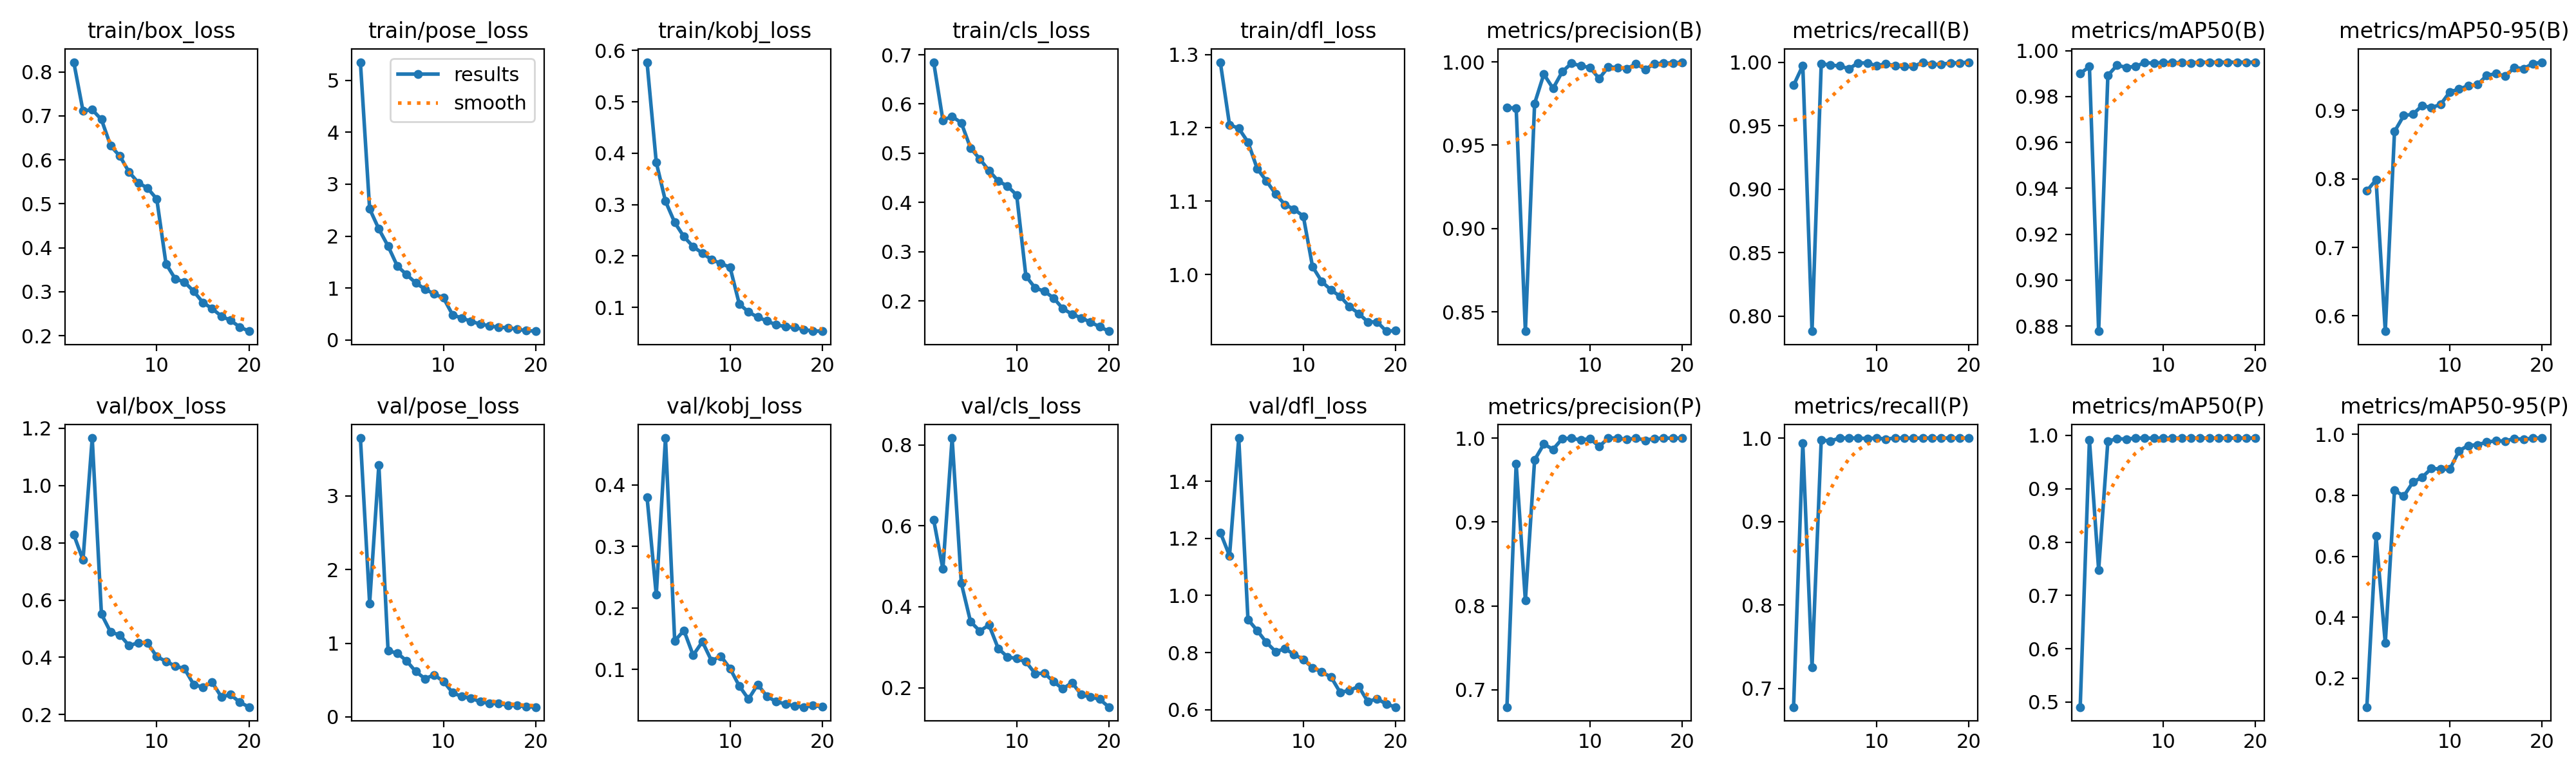

In [10]:
from IPython.display import Image, display

# Training curves
display(Image(filename="/content/runs/pose/results.png", width=800))

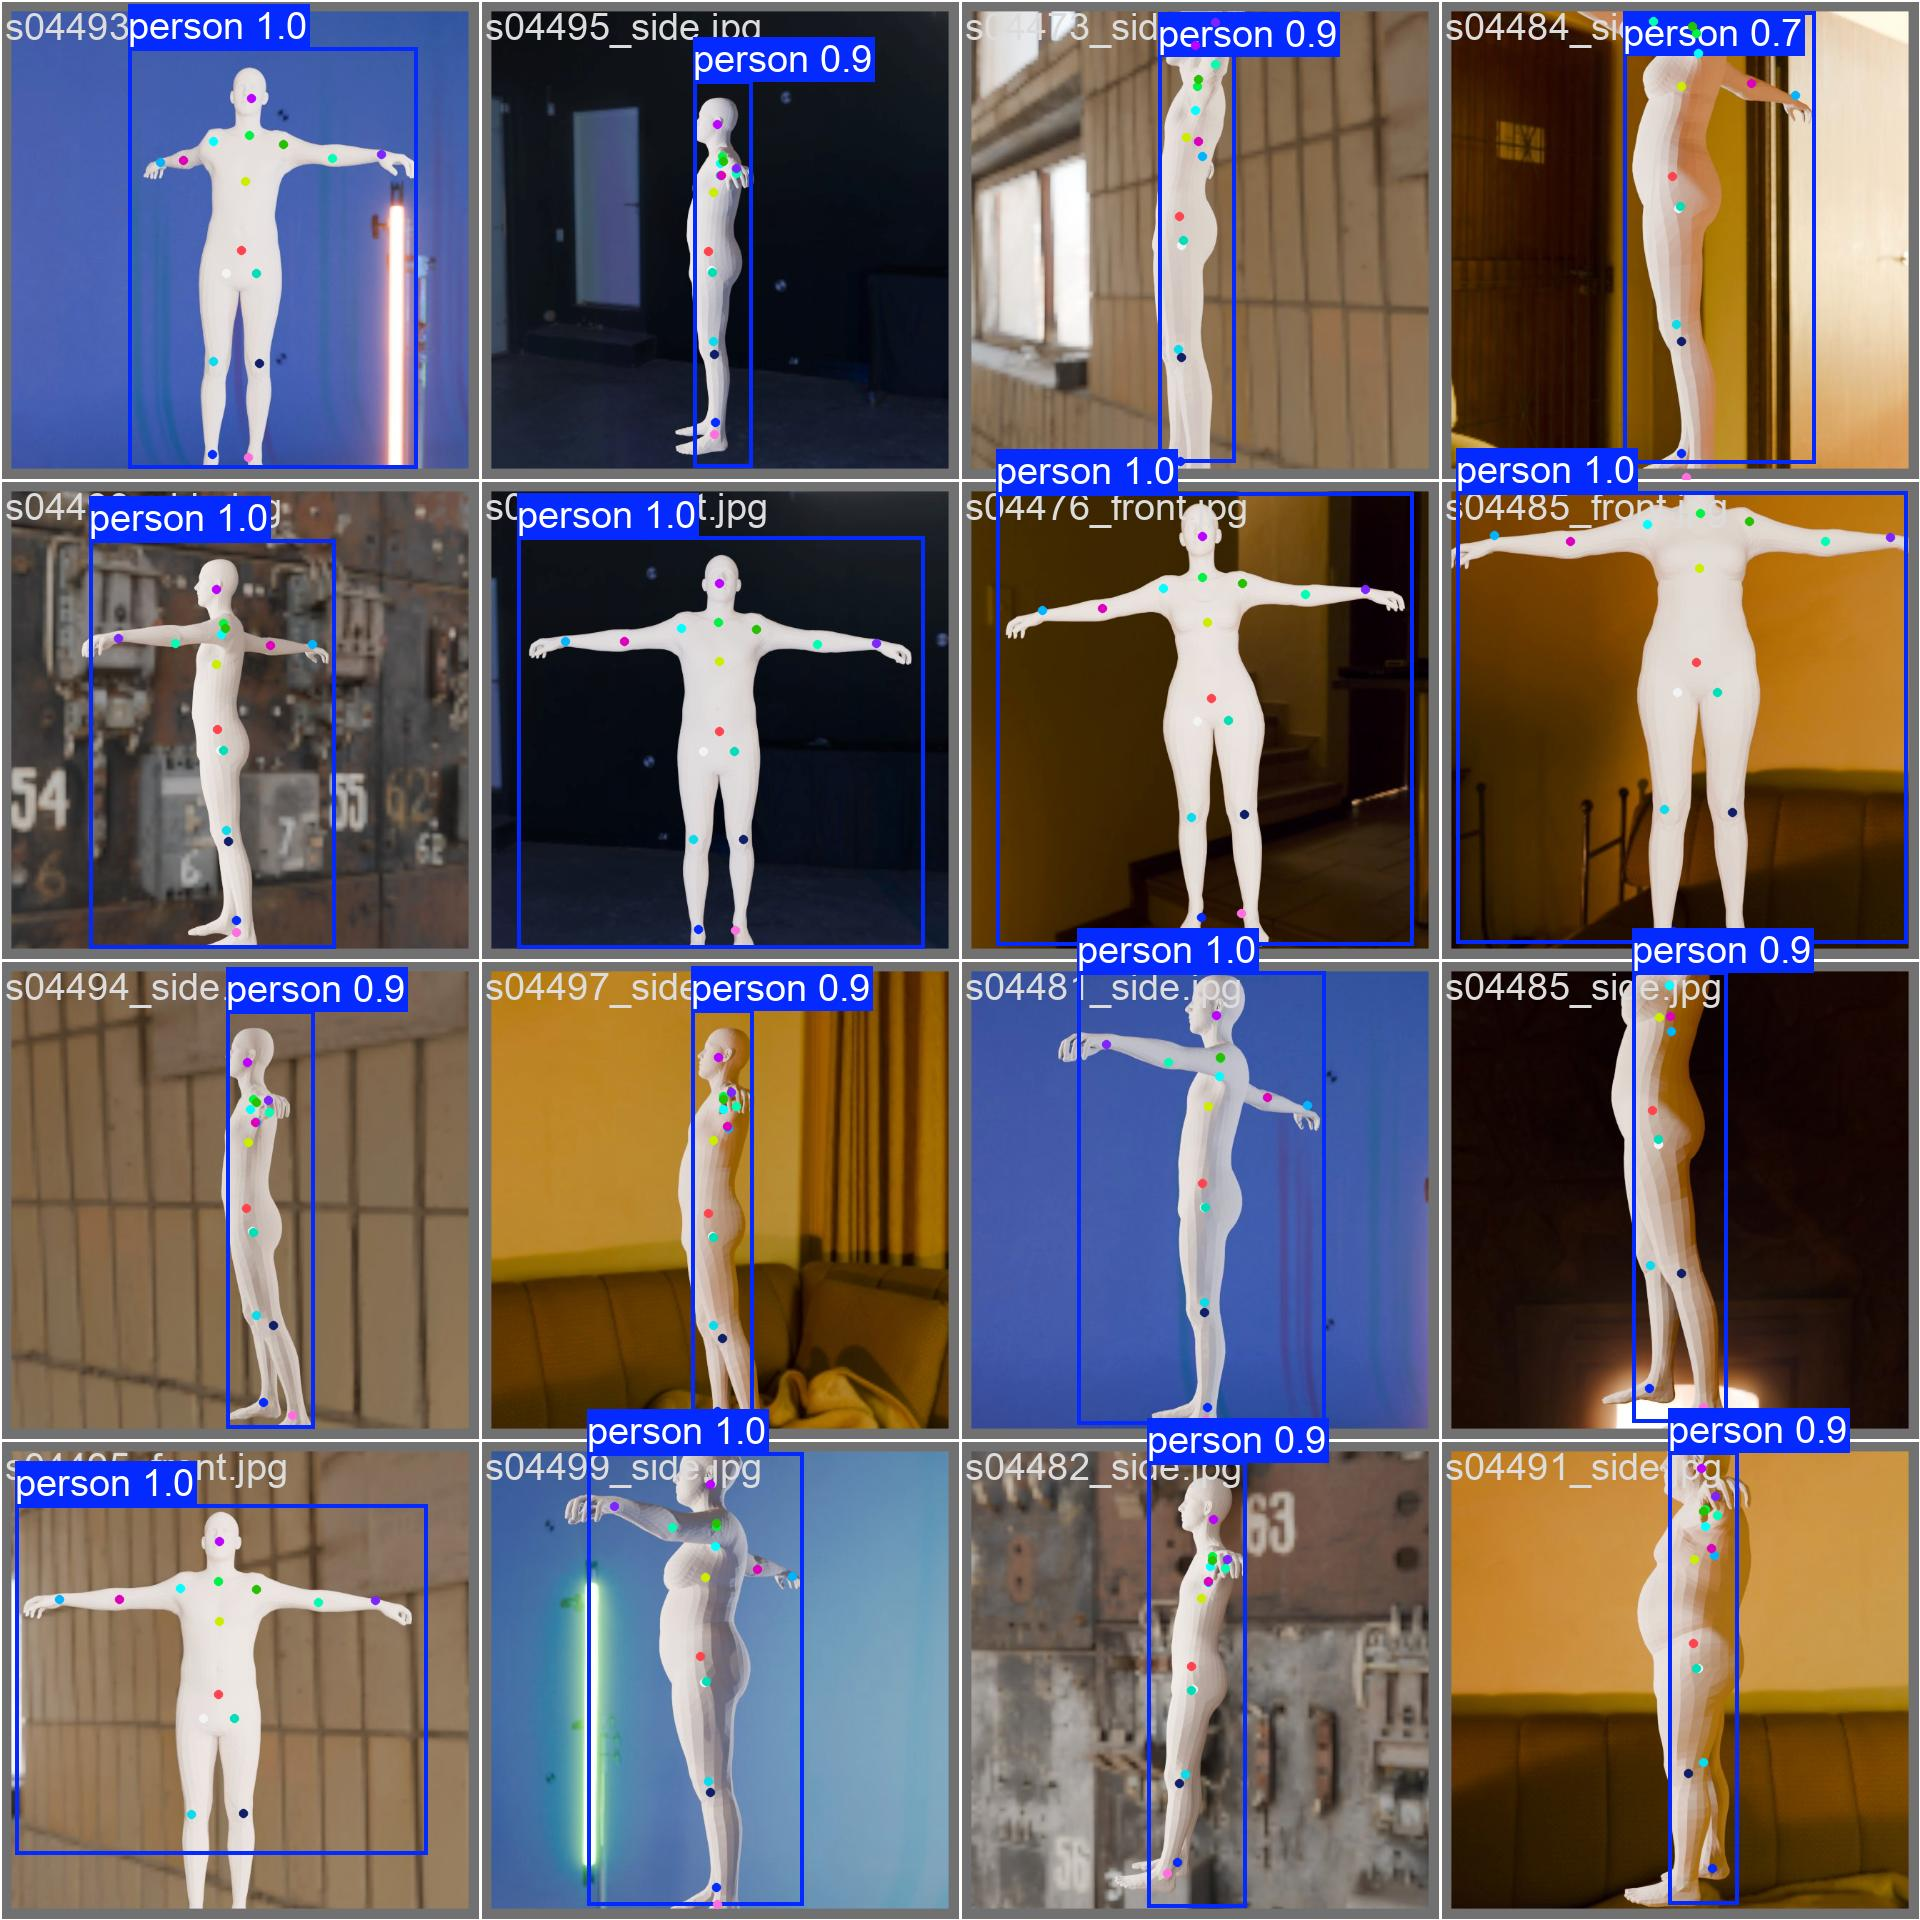

In [11]:
# Validation predictions
display(Image(filename="/content/runs/pose/val_batch0_pred.jpg", width=800))

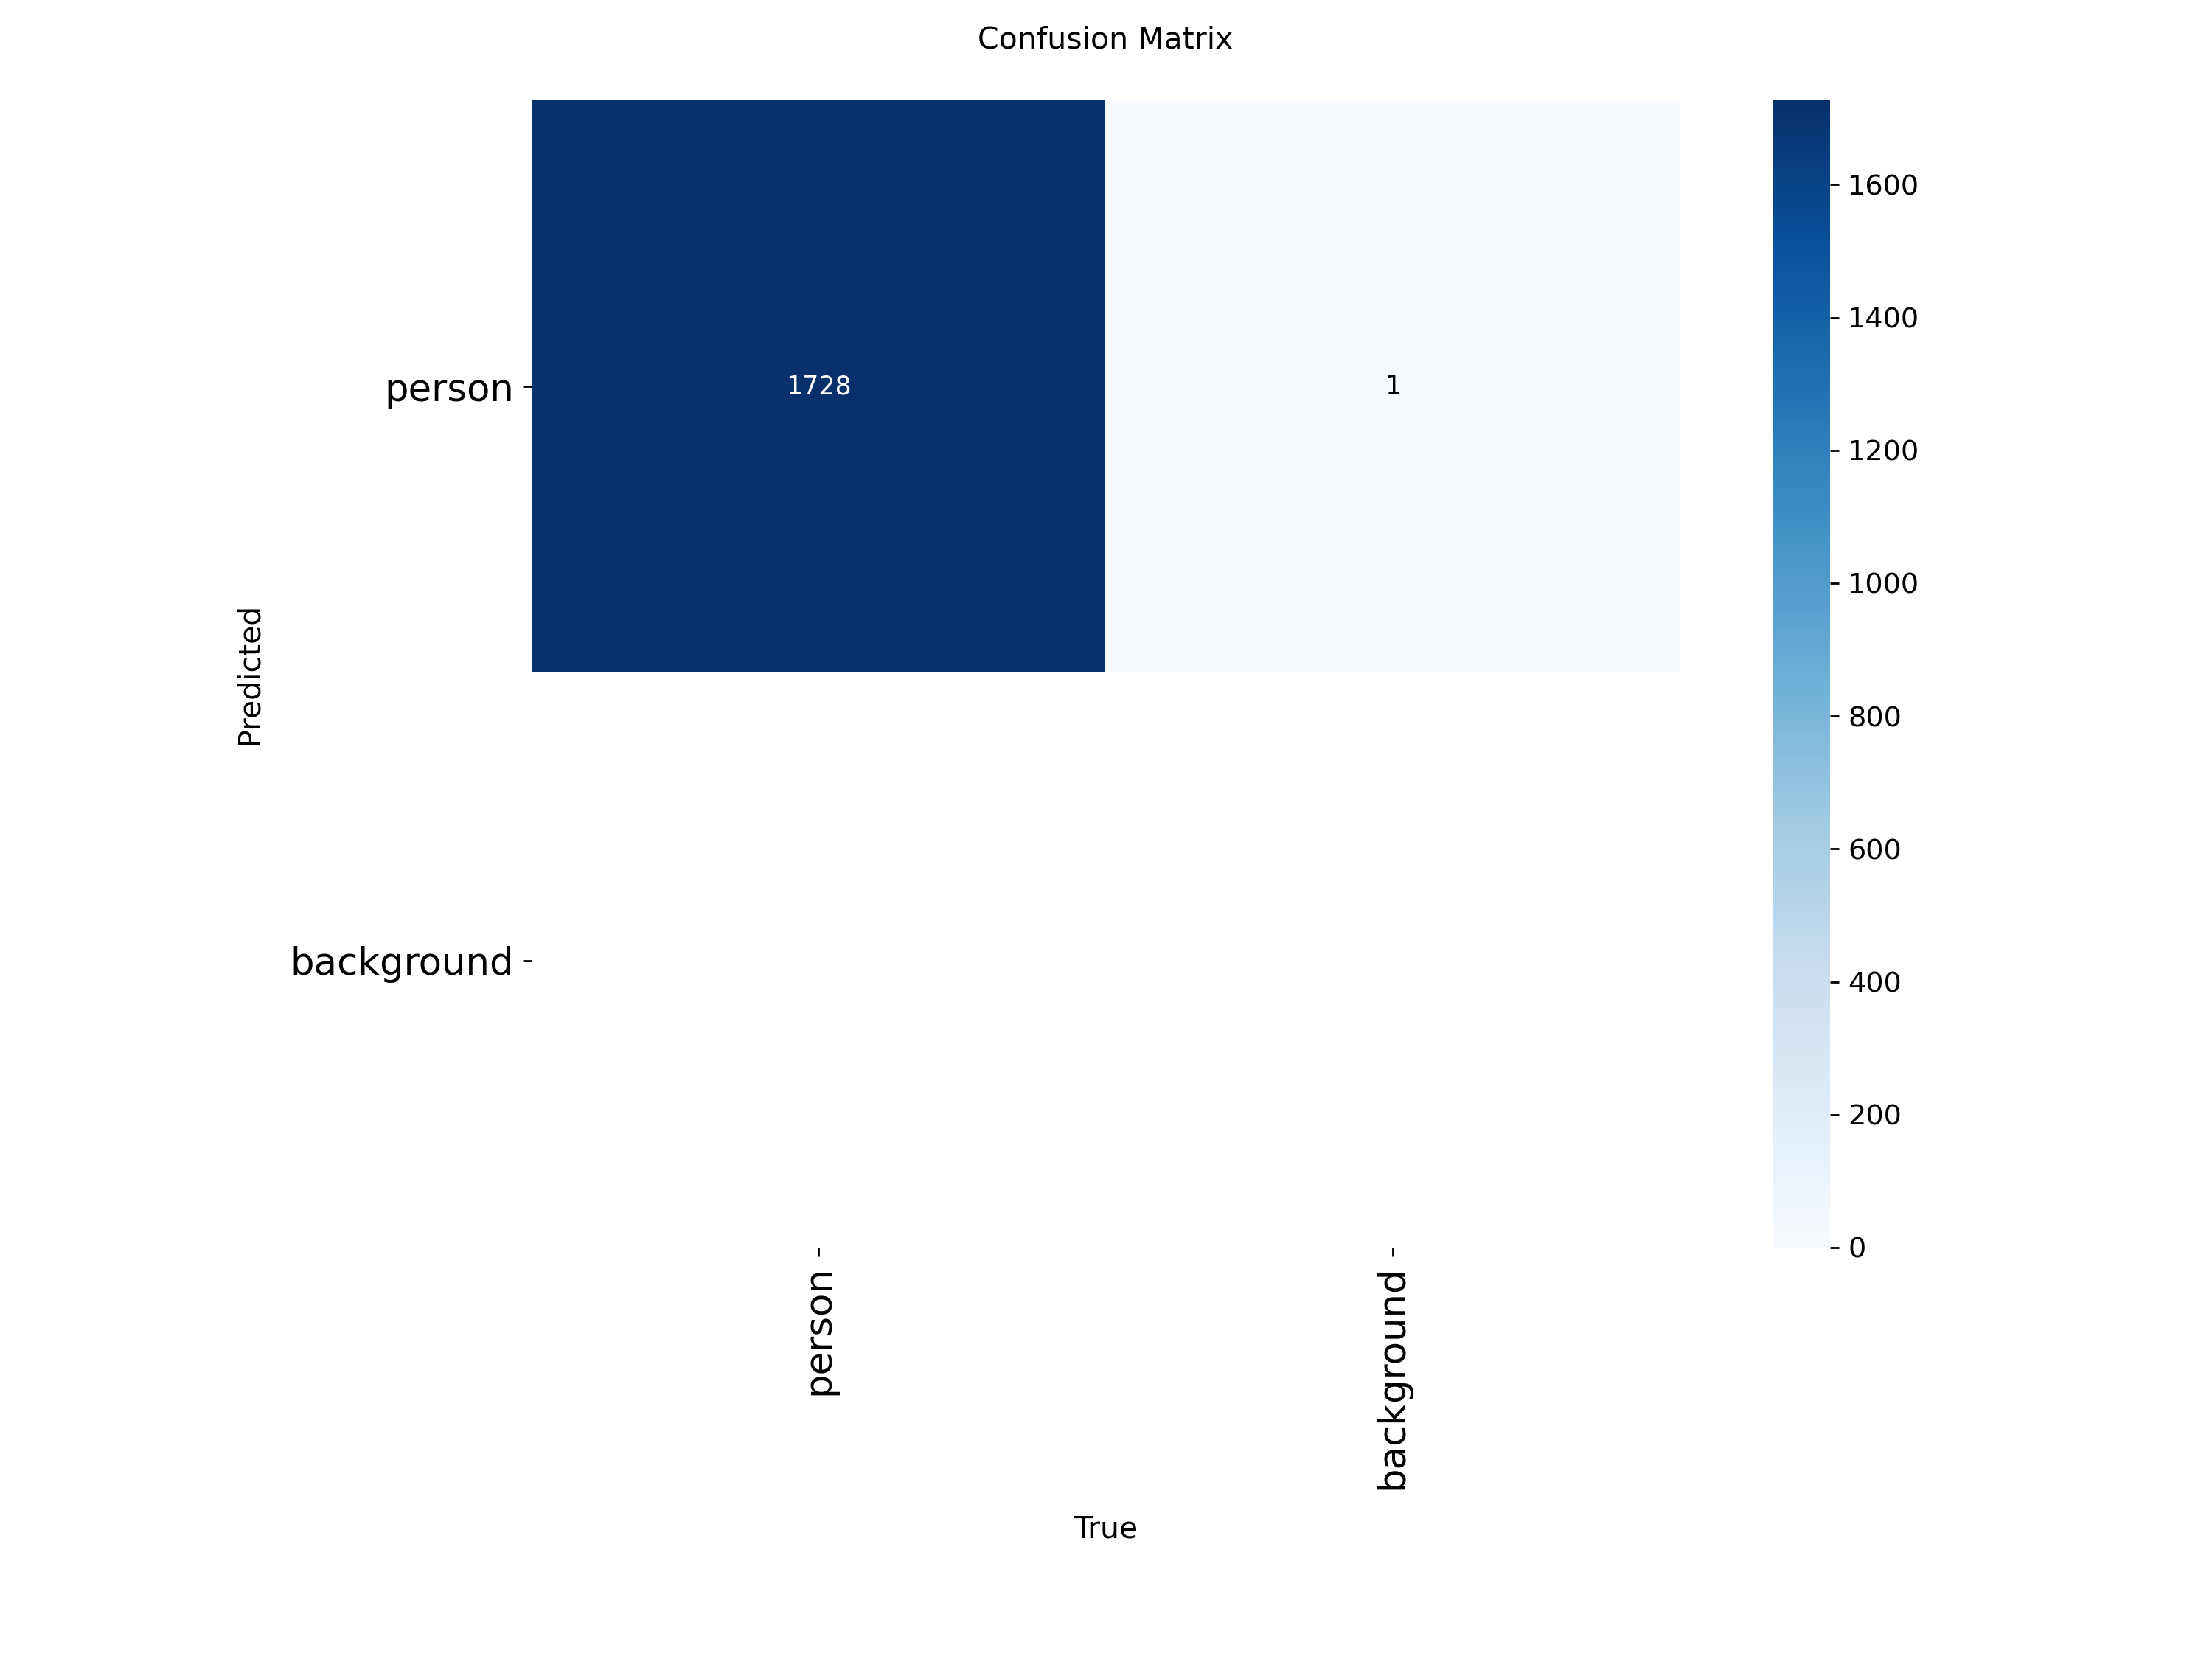

In [12]:
# Confusion matrix
display(Image(filename="/content/runs/pose/confusion_matrix.png", width=600))

## 8. Validate Best Model

In [13]:
best_model = YOLO("/content/runs/pose/weights/best.pt")
metrics = best_model.val(data=DATASET_YAML)

print(f"\nBox mAP50: {metrics.box.map50:.4f}")
print(f"Box mAP50-95: {metrics.box.map:.4f}")
print(f"Pose mAP50: {metrics.pose.map50:.4f}")
print(f"Pose mAP50-95: {metrics.pose.map:.4f}")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-pose summary (fused): 110 layers, 2,845,435 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 843.0±380.5 MB/s, size: 31.0 KB)
val: Scanning /content/synthetic-pose/val/labels.cache... 1728 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1728/1728 658.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 5.0it/s 21.7s
                   all       1728       1728          1          1      0.995       0.97          1          1      0.995      0.987
Speed: 1.4ms preprocess, 4.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/pose/val

Box mAP50: 0.9950
Box mAP50-95: 0.9703
Pose mAP50: 0.9950
Pose mAP50-95: 0.9873


## 9. Test Inference


0: 640x640 1 person, 17.2ms
1: 640x640 1 person, 17.2ms
2: 640x640 1 person, 17.2ms
3: 640x640 1 person, 17.2ms
Speed: 3.4ms preprocess, 17.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


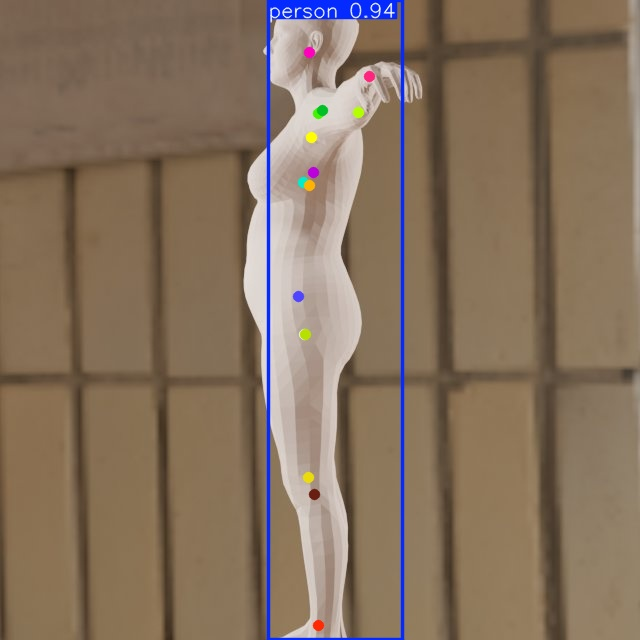

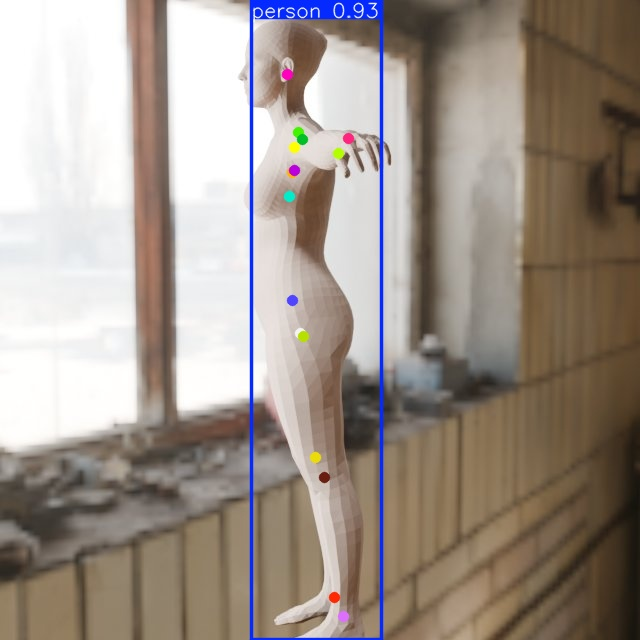

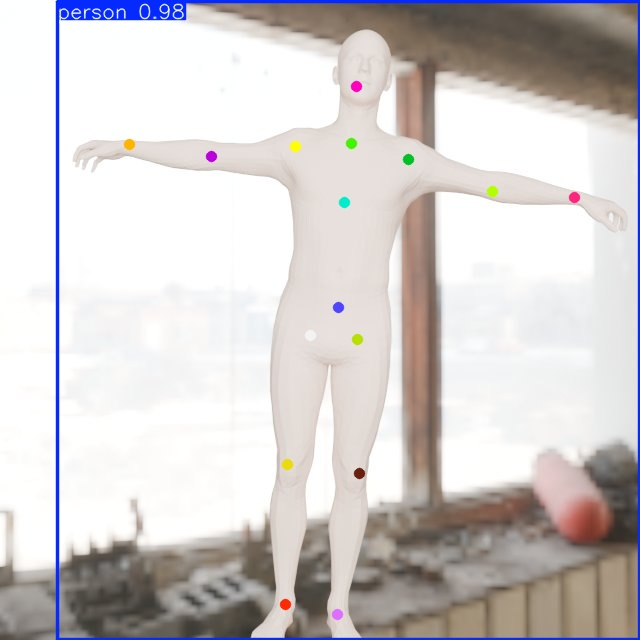

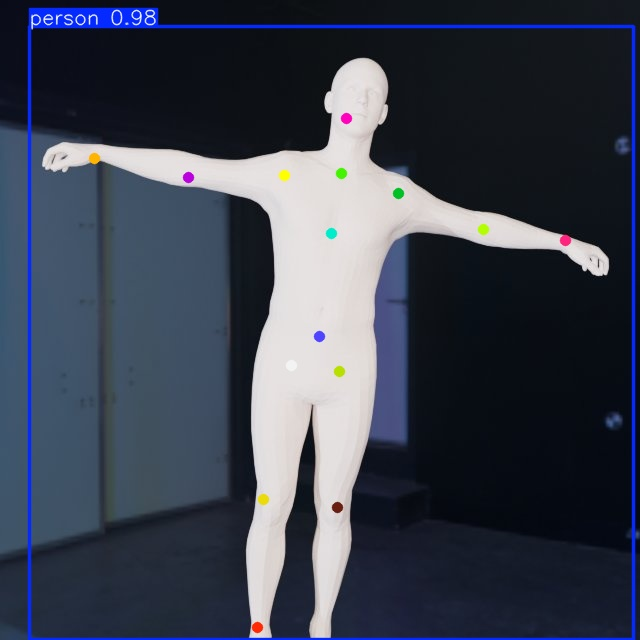

In [14]:
import glob

# Run inference on a few validation images
val_images = sorted(glob.glob(f"{LOCAL_DATASET_DIR}/val/images/*.jpg"))[:4]
results = best_model(val_images, imgsz=640)

for r in results:
    im = r.plot()
    display(Image(data=r.save(filename=None)))

## 10. Save Best Model to Google Drive

In [15]:
import shutil

DRIVE_OUTPUT = "/content/drive/MyDrive/PointsX/runs/pose"
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

# Copy best and last weights
for name in ["best.pt", "last.pt"]:
    src = f"/content/runs/pose/weights/{name}"
    dst = f"{DRIVE_OUTPUT}/{name}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Saved: {dst}")

# Copy results
for name in ["results.csv", "results.png"]:
    src = f"/content/runs/pose/{name}"
    dst = f"{DRIVE_OUTPUT}/{name}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Saved: {dst}")

print("\nAll results saved to Google Drive!")

Saved: /content/drive/MyDrive/PointsX/runs/pose/best.pt
Saved: /content/drive/MyDrive/PointsX/runs/pose/last.pt
Saved: /content/drive/MyDrive/PointsX/runs/pose/results.csv
Saved: /content/drive/MyDrive/PointsX/runs/pose/results.png

All results saved to Google Drive!
